In [14]:
import os
import pandas as pd
from openai import OpenAI

import numpy as np
import json
from dotenv import load_dotenv

import tiktoken
from copy import deepcopy
import re
import glob

repo_dir = "/Users/haya1/Documents/LanguageModel_Labels/congressional_bills"
os.chdir(repo_dir)

# Place API_KEY in the .env file
load_dotenv()
client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY_ASHESH'))
# client = OpenAI(api_key=os.environ.get('OPENAI_API_KEY'))

data_dir = os.path.join(repo_dir, "01_bills")
llm_dir = os.path.join(repo_dir, "02_llm")

# Create the MAJOR_TEXT dictionary
MAJOR_TEXT = pd.read_csv(os.path.join(data_dir, "majors.csv")).set_index('Major')['MajorText'].to_dict()


## Generate prompts

### Create `prompting_strategies.csv`

In [47]:
# prompting_strategies_csv_path = os.path.join(llm_dir, "prompting_strategies.csv")
# if os.path.exists(prompting_strategies_csv_path):
#     prompting_strategies = pd.read_csv(prompting_strategies_csv_path)
# else:
prompting_strategies = pd.DataFrame(data = {
    "PromptingStrategyName": [
        "Base Prompt", "Base Prompt", 
        "Persona", "Persona", "Persona", "Persona", 
        "Chain-of-Thoughts", "Chain-of-Thoughts", "Chain-of-Thoughts", 
        "Few-Shot", "Few-Shot", "Few-Shot"
        ],

    "Text": [
        None, None, 
        "You are a knowledgeable political analyst. ",
        "Answer this question as if you are a political scientist that studies legislation in the United States Congress. ",
        "Answer this question as if you are an expert in United States politics. ",
        "Answer this question as if you were a helpful research assistant for a political scientist. ",
        "Think carefully. ", 
        "Let's think step by step. Lay out each step. ", 
        "Please provide an explanation for your answer. ",
        None, None, None,
        ],

    "TextLocation": [
        None, None, 
        "before", "before", "before", "before", 
        "after", "after", "after", 
        None, None, None],

    "ExamplesPath": [
        None, None, 
        None, None, None, None, 
        None, None, None, 
        os.path.join(data_dir, "examples01.csv"),
        os.path.join(data_dir, "examples02.csv"),
        os.path.join(data_dir, "examples03.csv")
    ],

    "ResponseFormat": [
        "Fill-in-the-Blanks", "JSON", 
        "JSON", "JSON", "JSON", "JSON", 
        "JSON", "JSON", "JSON", 
        "JSON", "JSON", "JSON"
    ],

    # InputTokens and OuputTokens estimations are based on average run of 100 bills
    "InputTokensAverage": [
        239.96, 242.96, 
        249.96, 261.96, 256.96, 258.96, 
        260.96, 269.96, 265.96, 
        1599.96, 1562.96, 1547.96
    ], 
    "InputTokensSD": [12.53]*12, 
    "OutputTokensAverage": [
        5.96, 19, 
        19, 19, 19, 19, 
        47.56, 47.47, 48.36, 
        15, 15, 15
    ], 
    "OutputTokensSD": [
        0.2, 0.00, 
        0.00, 0.00, 0.00, 0.00, 
        4.41, 4.72, 5.29, 
        0.00, 0.00, 0.00]
})
prompting_strategies.insert(loc=4, column="AddExamples", value=prompting_strategies["PromptingStrategyName"] == "Few-Shot")
prompting_strategies["AddExplanation"] = prompting_strategies["PromptingStrategyName"] == "Chain-of-Thoughts"

n = len(prompting_strategies)
prompting_strategies = pd.concat([prompting_strategies, prompting_strategies], ignore_index=True)
prompting_strategies["Model"] = ["gpt-3.5-turbo-0125"]*n + ["gpt-4o"]*n
ModelInputCost_perToken = [0.50/1e6]*n + [5.00/1e6]*n # + [0.150/1e6]*n
ModelOutputCost_perToken = [1.50/1e6]*n + [15.0/1e6]*n # + [0.60/1e6]*n

prompting_strategies["TotalCostAverage_per10KBills"] = (
    (prompting_strategies["InputTokensAverage"] * ModelInputCost_perToken) + 
    (prompting_strategies["OutputTokensAverage"] * ModelOutputCost_perToken)) * 10e3

prompting_strategies.insert(loc=0, column="PromptingStrategyID", value = list(range(1, len(prompting_strategies)+1)))

prompting_strategies["Temperature"] = 0 
prompting_strategies.to_csv(os.path.join(llm_dir, "prompting_strategies.csv"), index=False, float_format='%.2f')

## Create `prompts.jsonl`

In [71]:
# Create the CATEGORIES string
CATEGORIES = "\n".join([f"{int(major)}. {text}" for major, text in MAJOR_TEXT.items()])

QUESTION =f"""Here is a description of a bill introduced in the U.S. Congress:
"{{0}}"

Please classify this description into one of the following categories:
{CATEGORIES}
"""

ANSWER_JSON = f"""Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category,
    "Confidence": confidence level in the bill classification as a number between 0 to 1 with 2 decimal places
}}}}
"""

ANSWER_JSON_EXPLANATION = f"""Output a JSON object structured like: {{{{
    "Category": an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category,
    "Confidence": confidence level in the bill classification as a number between 0 to 1 with 2 decimal places,
    "Explanation": a one-sentence explanation for your chosen bill category
}}}}
"""

ANSWER_BLANKS = f"""Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category),
____ (fill in with confidence level in the bill classification as a number between 0 to 1 with 2 decimal places)
"""

ANSWER_BLANKS_EXPLANATION = f"""Write your answer as:
____ (fill in with an integer from {min(MAJOR_TEXT.keys())} to {max(MAJOR_TEXT.keys())} that best represents the bill category),
____ (fill in with confidence level in the bill classification as a number between 0 to 1 with 2 decimal places),
____ (fill in with a one-sentence explanation for your chosen bill category)
"""

In [9]:
def create_content_user(strategy):
    question = QUESTION + "\n"
    if strategy["TextLocation"] == "before":
        question = strategy["Text"] + question
    elif strategy["TextLocation"] == "after":
        question = question + strategy["Text"]

    if strategy["ResponseFormat"]=="JSON":
        if strategy["AddExplanation"]:
            answer = ANSWER_JSON_EXPLANATION
        else:
            answer = ANSWER_JSON
    else:
        if strategy["AddExplanation"]:
            answer = ANSWER_BLANKS_EXPLANATION
        else:
            answer = ANSWER_BLANKS

    content = question + answer
    return content

def create_content_assistant(strategy, category, confidence, explanation=None):
    if strategy["ResponseFormat"]=="JSON":
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2),
                "Explanation": explanation
            }
        else:
            correct_answer = {
                "Category": category,
                "Confidence": np.round(confidence, decimals=2)
            }
        content = json.dumps(correct_answer)

    else:
        if strategy["AddExplanation"]:

            if explanation is None:
                raise Exception("AddExplanation=True but explanation=None. You need to pass a string to explanation variable")
            
            correct_answer = "%d, %.2f, %s\n" % (category, confidence, explanation)
        else:
            correct_answer = "%d, %.2f\n" % (category, confidence)
        content = correct_answer

    return content

def create_messages(strategy, min_confidence, max_confidence=1, examples_via_system=True):
    messages = []

    if strategy["AddExamples"]:
        bills_examples = pd.read_csv(strategy["ExamplesPath"])
        
        for _, bill in bills_examples.iterrows():
            message_user_content = create_content_user(strategy).format(bill["Description"])

            if examples_via_system:
                message_user = {"role": "system", "name": "example_user", "content": message_user_content}
            else:
                message_user = {"role": "user", "content": message_user_content}
            messages.append(message_user)

            message_assistant_content = create_content_assistant(strategy, category=bill["Major"], confidence=np.random.uniform(min_confidence, max_confidence))
            if examples_via_system:
                message_assistant = {"role": "system", "name": "example_assistant", "content": message_assistant_content}
            else:
                message_assistant = {"role": "assistant", "content": message_assistant_content}
            messages.append(message_assistant)
    
    message_user_content = create_content_user(strategy)
    message_user = {"role": "user", "content": message_user_content}
    messages.append(message_user)
    return messages

def count_tokens(messages, model="gpt-3.5-turbo"):
    encoding = tiktoken.encoding_for_model(model)
    
    if model in {"gpt-3.5-turbo-0125", "gpt-3.5-turbo", "gpt-4o"}:
        tokens_per_message = 3
        tokens_per_name = 1
    else:
        raise NotImplementedError(f"No implementation for model {model}.")
    num_tokens = 0
    for message in messages:
        num_tokens += tokens_per_message
        for key, value in message.items():
            num_tokens += len(encoding.encode(value))
            if key == "name":
                num_tokens += tokens_per_name
    num_tokens += 3  # every reply is primed with <|start|>assistant<|message|>
    return num_tokens

In [10]:
n = 9000
prompting_strategies = pd.read_csv(os.path.join(llm_dir, "prompting_strategies.csv"))
bills = pd.read_csv(os.path.join(data_dir, f"bills_without_examples_{n}.csv"))
prompts_path = os.path.join(llm_dir, f"prompts_{n}.jsonl")

prompting_strategies_json = []
for _, strategy in prompting_strategies.iterrows():
    strategy_json = {
        "PromptingStrategyID": strategy["PromptingStrategyID"],
        "PromptingStrategyName": strategy["PromptingStrategyName"],
        "ResponseFormat": strategy["ResponseFormat"],
        "AddExplanation": strategy["AddExplanation"],
        "AddExamples": strategy["AddExamples"],
        "Model": strategy["Model"],
        "Temperature": strategy["Temperature"],
        "Messages": create_messages(strategy, min_confidence=0.9, max_confidence=1, examples_via_system=True)
    }
    prompting_strategies_json.append(strategy_json)
    
prompting_strategies_json = pd.json_normalize(prompting_strategies_json)

id = 0
prompts = []
for _, bill in bills.iterrows():
    for _, strategy in prompting_strategies_json.iterrows():
        
        # add bill to last used message
        bill_messages = deepcopy(strategy["Messages"])
        bill_messages[-1]["content"] = bill_messages[-1]["content"].format(bill["Description"])
        
        input_tokens = count_tokens(bill_messages, strategy['Model'])
        output_tokens = 0

        id = id + 1
        prompt = {
            "ID": id,
            "BillID": bill["BillID"],
            "PromptingStrategyID": strategy["PromptingStrategyID"],
            "Description": bill["Description"],
            "PromptingStrategyName": strategy["PromptingStrategyName"],
            "ResponseFormat": strategy["ResponseFormat"],
            "AddExplanation": strategy["AddExplanation"],
            "AddExamples": strategy["AddExamples"],
            "Model": strategy["Model"],
            "Temperature": strategy["Temperature"],
            "Major": bill["Major"],
            "MajorText": bill["MajorText"],
            "InputTokens": input_tokens,
            "Messages": bill_messages
        }
        prompts.append(prompt)


with open(prompts_path, "w") as f:
    for prompt in prompts:
        f.write(json.dumps(prompt) + "\n")
print(f"Saved {prompts_path}")

Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_9000.jsonl


### Create `prompts_batched.jsonl`

In [106]:
n = 10000
prompts_path = os.path.join(llm_dir, f"prompts_{n}.jsonl")
prompts = pd.read_json(prompts_path, lines=True)

for model in prompts["Model"].unique(): # ["gpt-3.5-turbo-0125", "gpt-4o"]
    prompts_model = prompts[prompts["Model"]==model].reset_index()

    prompts_batched = []
    part = 0
    for i, prompt in prompts_model.iterrows():
        prompt_batched = {
                "custom_id": "ID_" + str(prompt["ID"]),
                "method": "POST",
                "url": "/v1/chat/completions",
                "body": {
                    "model": prompt["Model"],
                    "temperature": prompt["Temperature"],
                    "response_format": {"type": "json_object"} if (prompt["ResponseFormat"]=="JSON") else None,
                    "messages": prompt["Messages"],
                }
            }
        prompts_batched.append(prompt_batched)

        if ((i==(12e3-1)) | (len(prompts_batched)==50e3) | (i==(len(prompts_model)-1))):
            part = part + 1
            prompts_batched_path = os.path.join(llm_dir, f"prompts_batched_{n}_{model}_part{part}.jsonl")
            with open(prompts_batched_path, "w") as f:
                for prompt_batched in prompts_batched:
                    f.write(json.dumps(prompt_batched) + "\n")
                print(f"Saved {prompts_batched_path}")
            prompts_batched = []


Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-3.5-turbo-0125_part1.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-3.5-turbo-0125_part2.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-3.5-turbo-0125_part3.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-3.5-turbo-0125_part4.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-4o_part1.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-4o_part2.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-4o_part3.jsonl
Saved /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/prompts_batched_10000_gpt-4o_part4.jsonl


## Estimate Cost using Batch API

In [3]:
PRICES = {
    'gpt-3.5-turbo-0125': {
        'input': 0.25/1e6, 
        'output': 0.75/1e6
    },
    'gpt-4o': {
        'input': 2.5/1e6, 
        'output': 7.5/1e6
    },
}

def estimate_cost(prompts):
    if "OutputTokensEstimate" not in prompts.columns: 
        prompting_strategies = pd.read_csv(os.path.join(llm_dir, "prompting_strategies.csv"))
        prompting_strategies.set_index("PromptingStrategyID", inplace=True, drop=False) 
        prompts["OutputTokensEstimate"] = prompts["PromptingStrategyID"].apply(lambda x: prompting_strategies.loc[x, "OutputTokensAverage"])

    input_tokens_cost = prompts["InputTokens"] * prompts["Model"].apply(lambda x: PRICES.get(x).get('input'))
    output_tokens_cost = prompts["OutputTokensEstimate"] * prompts["Model"].apply(lambda x: PRICES.get(x).get('output'))
    total_cost = (input_tokens_cost + output_tokens_cost).sum()
    return total_cost

In [5]:
n = 10000
prompts_path = os.path.join(llm_dir, f"prompts_{n}.jsonl")
prompts = pd.read_json(prompts_path, lines=True)
print(f"Estimated cost of running {os.path.basename(prompts_path)} is ${estimate_cost(prompts):.2f}")

Estimated cost of running prompts_10000.jsonl is $220.97


## Generate responses

In [38]:
batches = {}

prompts_batched_paths = glob.glob(os.path.join(llm_dir, f'prompts_batched_{n}_*.jsonl'))

for prompts_batched_path in prompts_batched_paths:
    batch_input_file = client.files.create(
        file = open(prompts_batched_path, "rb"),
        purpose = "batch"
    )
    batch_input_file_id = batch_input_file.id
    batch = client.batches.create(
            input_file_id = batch_input_file_id,
            endpoint = "/v1/chat/completions",
            completion_window = "24h",
            metadata = {"description": f"{os.path.basename(prompts_batched_path)}"}
        )
    
    batches[os.path.basename(prompts_batched_path)] = batch.id

batches

{'prompts_batched_9000_gpt-4o_part1.jsonl': 'batch_k0XxH5uZU78uyloLs8IYIBwh',
 'prompts_batched_9000_gpt-4o_part3.jsonl': 'batch_8EFmBWRWBFJuStCPbO26rhQ3',
 'prompts_batched_9000_gpt-3.5-turbo-0125_part3.jsonl': 'batch_pvocTdpKJAeylK6tdHxvpZmu',
 'prompts_batched_9000_gpt-3.5-turbo-0125_part1.jsonl': 'batch_6yCzX3zUgi7xKFzWx7Y3wCih',
 'prompts_batched_9000_gpt-4o_part2.jsonl': 'batch_0IR9IRoYYJb6TYYvvN8XqXk2',
 'prompts_batched_9000_gpt-3.5-turbo-0125_part2.jsonl': 'batch_zK9n9beqzKH84y8k45IO4Hep'}

In [7]:
batches = {
    'prompts_batched_10000_gpt-3.5-turbo-0125_part1.jsonl': {'part': 1, 'id': 'batch_tSVIpwOEqYLYIxrzneZ38Cf8'}, #12e3, this was the 1000 bill run, , prompts_batched_1000_gpt-3.5-turbo-0125.json
    'prompts_batched_10000_gpt-3.5-turbo-0125_part2.jsonl': {'part': 2, 'id': 'batch_6yCzX3zUgi7xKFzWx7Y3wCih'}, #50e3, prompts_batched_9000_gpt-3.5-turbo-0125_part1.json
    'prompts_batched_10000_gpt-3.5-turbo-0125_part3.jsonl': {'part': 3, 'id': 'batch_zK9n9beqzKH84y8k45IO4Hep'}, #50e3, prompts_batched_9000_gpt-3.5-turbo-0125_part2.json
    'prompts_batched_10000_gpt-3.5-turbo-0125_part4.jsonl': {'part': 4, 'id': 'batch_pvocTdpKJAeylK6tdHxvpZmu'}, #8e3, prompts_batched_9000_gpt-3.5-turbo-0125_part3.json
    'prompts_batched_10000_gpt-4o_part1.jsonl': {'part': 1, 'id': 'batch_Qi4lin1f66j96pho3ofhRxyl'}, #12e3, this was the 1000 bill run, prompts_batched_1000_gpt-4o.json
    'prompts_batched_10000_gpt-4o_part2.jsonl': {'part': 2, 'id': 'batch_k0XxH5uZU78uyloLs8IYIBwh'}, #50e3, prompts_batched_9000_gpt-4o_part1.json
    'prompts_batched_10000_gpt-4o_part3.jsonl': {'part': 3, 'id': 'batch_0IR9IRoYYJb6TYYvvN8XqXk2'}, #50e3, prompts_batched_9000_gpt-4o_part2.json
    'prompts_batched_10000_gpt-4o_part4.jsonl': {'part': 4, 'id': 'batch_8EFmBWRWBFJuStCPbO26rhQ3'},  #8e3, prompts_batched_9000_gpt-4o_part3.json
    }

In [8]:
# Check status of all batches
for file in batches:
    id = batches[file]['id']
    batch_status = client.batches.retrieve(id)
    print(f"{file:>52s}: {batch_status.status}")

prompts_batched_10000_gpt-3.5-turbo-0125_part1.jsonl: completed
prompts_batched_10000_gpt-3.5-turbo-0125_part2.jsonl: completed
prompts_batched_10000_gpt-3.5-turbo-0125_part3.jsonl: completed
prompts_batched_10000_gpt-3.5-turbo-0125_part4.jsonl: completed
            prompts_batched_10000_gpt-4o_part1.jsonl: completed
            prompts_batched_10000_gpt-4o_part2.jsonl: completed
            prompts_batched_10000_gpt-4o_part3.jsonl: completed
            prompts_batched_10000_gpt-4o_part4.jsonl: completed


In [10]:
for file in batches:
    batch_id = batches[file]['id']
    part = batches[file]['part']
    batch_status = client.batches.retrieve(batch_id)
    
    if batch_status.status != "completed":
        print(f"Skipping incomplete file = {file}, Batch ID = {batch_id}")
        continue
    
    output_file_id = batch_status.output_file_id
    responses_batched = client.files.content(output_file_id)

    responses_batched_path = os.path.join(llm_dir, file.replace("prompts", "responses"))
    responses_batched.write_to_file(responses_batched_path)

    # if not part 1, we correct the ID as it shouldn't start from 1
    if (part!=1):
        responses_batched = pd.read_json(responses_batched_path, lines=True)
        responses_batched["custom_id"] = responses_batched["custom_id"].apply(lambda x: "ID_" + str(int(x[3:]) + int(1000*24))) 
        responses_batched.to_json(responses_batched_path, orient='records', lines=True)

    print(f"Saved raw responses at {responses_batched_path}")

Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part1.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part2.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part3.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part4.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-4o_part1.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-4o_part2.jsonl
Saved raw responses at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-4o_part3

In [12]:
n = 10000
responses_path = os.path.join(llm_dir, f"responses_{n}.csv")

responses_batched = []
for responses_batched_path in sorted(glob.glob(os.path.join(llm_dir, f'responses_batched_{n}_*.jsonl'))):
    responses_batched_file = pd.read_json(responses_batched_path, lines=True)
    print(f"Loaded {responses_batched_path}, n = {len(responses_batched_file)}")
    responses_batched_file["ID"] = responses_batched_file["custom_id"].apply(lambda x: int(x[3:]))
    responses_batched.append(responses_batched_file)

responses_batched = pd.concat(responses_batched)
print(f"Appended all responses, n = {len(responses_batched)}")


Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part1.jsonl, n = 12000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part2.jsonl, n = 50000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part3.jsonl, n = 50000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-3.5-turbo-0125_part4.jsonl, n = 8000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-4o_part1.jsonl, n = 12000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-4o_part2.jsonl, n = 50000
Loaded /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm/responses_batched_10000_gpt-4o_part3.jsonl, n = 50000
Loaded /Users/haya1/Documents

## Decode Responses

In [15]:
prompts = pd.read_json(prompts_path, lines=True)[["ID", "BillID", "ResponseFormat", "AddExplanation"]]
responses_batched = responses_batched.merge(prompts, on="ID")
responses_batched.set_index("ID", inplace=True, drop=False)
responses_batched.sort_index(inplace=True)

responses = []
for _, response_batched in responses_batched.iterrows(): # range(len(responses_batched)):
    # response_batched = responses_batched.iloc[i]
    # prompt = prompts.iloc[i] # [prompts["ID"]==response_batched["ID"]]
    
    response_text = response_batched.response["body"]["choices"][0]["message"]["content"]

    if response_batched["ResponseFormat"]=="JSON":
        temp = json.loads(response_text)
        major = int(temp["Category"])
        response = {
            "ID": response_batched["ID"],
            "MajorLLM": major,
            "MajorTextLLM": MAJOR_TEXT[major],
            "ConfidenceLLM": float(temp["Confidence"]),
            "ExplanationLLM": temp["Explanation"] if response_batched["AddExplanation"] else None
        }

    else:
        single_entry_pattern = r'^(\d+)\s*[,]{0,1}\s*[\r\n]{0,1}\s*([0-9]\.[0-9]{2})\s*[,]{0,1}[\r\n]{0,1}?\s*(.*)?$'
        multiple_entries_pattern = r'((\d+)\s*\.\s*([\d\.]+)\s*\n)' 

        if re.match(single_entry_pattern, response_text):
            match = re.match(single_entry_pattern, response_text)
            major = int(match.group(1))
            response = {
                "ID": response_batched["ID"],
                "MajorLLM": major,
                "MajorTextLLM": MAJOR_TEXT[major],
                "ConfidenceLLM": float(match.group(2)),
                "ExplanationLLM": match.group(3) if response_batched["AddExplanation"] else None
            }
        elif re.findall(multiple_entries_pattern, response_text):
            print("hi")
            matches = re.findall(multiple_entries_pattern, response_text)
            match = max(matches, key=lambda x: float(x[2]))
            major = int(match[1])
            explanation = re.split('\n', response_text)[-1]
            response = {
                "ID": response_batched["ID"],
                "MajorLLM": major,
                "MajorTextLLM": MAJOR_TEXT[major],
                "ConfidenceLLM": float(match[2]),
                "ExplanationLLM": explanation if response_batched["AddExplanation"] else None
            }

    response["InputTokens"] = int(response_batched.response["body"]["usage"]["prompt_tokens"])
    response["OutputTokens"] = int(response_batched.response["body"]["usage"]["completion_tokens"])
    responses.append(response)

pd.json_normalize(responses).to_csv(responses_path, index=False, float_format='%.2f')    
print(f"Saved decoded responses at {responses_path}, n = {len(responses)}")

ValueError: 'ID' is both an index level and a column label, which is ambiguous.

In [ ]:
# Merge prompts and responses datasets
n = 10000
prompts_path = os.path.join(llm_dir, f"prompts_{n}.jsonl")
responses_path = os.path.join(llm_dir, f"responses_{n}.csv")
prompts_and_responses_path = os.path.join(llm_dir, f"prompts_and_responses_{n}.csv")
                                          
prompts = pd.read_json(prompts_path, lines=True)
prompts.drop(columns=["Messages", "InputTokens"], inplace=True)
responses = pd.read_csv(responses_path)

prompts_and_responses = prompts.merge(responses, on="ID")
prompts_and_responses.to_csv(prompts_and_responses_path, index=False, float_format='%.2f')
print(f"Merged prompts and responses data, bills = {len(prompts_and_responses['BillID'].unique())}, n_prompts = {len(prompts_and_responses)}. Saved at {llm_dir}")
# prompts_and_responses.head()

Merged prompts and responses data, bills = 10000, n_prompts = 240000. Saved at /Users/haya1/Documents/LanguageModel_Labels/congressional_bills/02_llm


## Unique MajorLLM

In [16]:
import os
import pandas as pd
import matplotlib.pyplot as plt

prompts_and_responses_path = os.path.join(llm_dir, f"prompts_and_responses_{n}.csv")
prompts_and_responses = pd.read_csv(prompts_and_responses_path)
n_bills = len(prompts_and_responses['BillID'].unique())
n_strategies = len(prompts_and_responses["PromptingStrategyID"].unique())
n_major = len(prompts_and_responses['Major'].unique())
print(f"Loaded responses.csv data, n = {len(prompts_and_responses)}")
print(f"Number of bills = {n_bills}")
print(f"Number of prompting strategies per bill = {n_strategies}")
print(f"Number of Major topic IDs = {n_major}")

Loaded responses.csv data, n = 240000
Number of bills = 10000
Number of prompting strategies per bill = 24
Number of Major topic IDs = 20


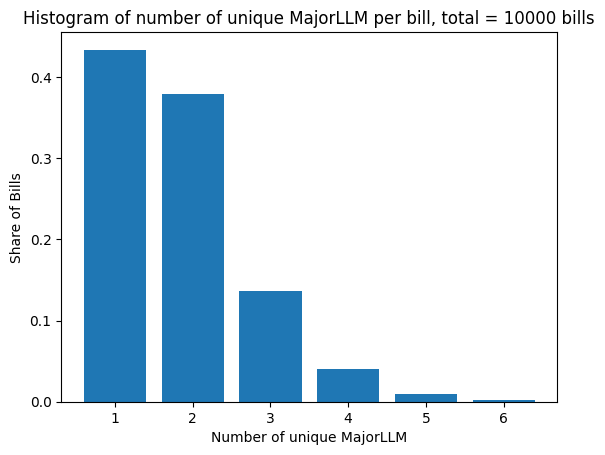

In [17]:
stat = prompts_and_responses.groupby(["BillID"]).agg(
    UniqueMajorLLM = ("MajorLLM", "nunique")
    ).reset_index()

labels, counts = np.unique(stat["UniqueMajorLLM"], return_counts=True)
shares = counts/n_bills
plt.bar(labels, shares, align='center')
plt.gca().set_xticks(labels)
plt.title(f'Histogram of number of unique MajorLLM per bill, total = {n_bills} bills')
plt.xlabel('Number of unique MajorLLM')
plt.ylabel('Share of Bills')
plt.show()

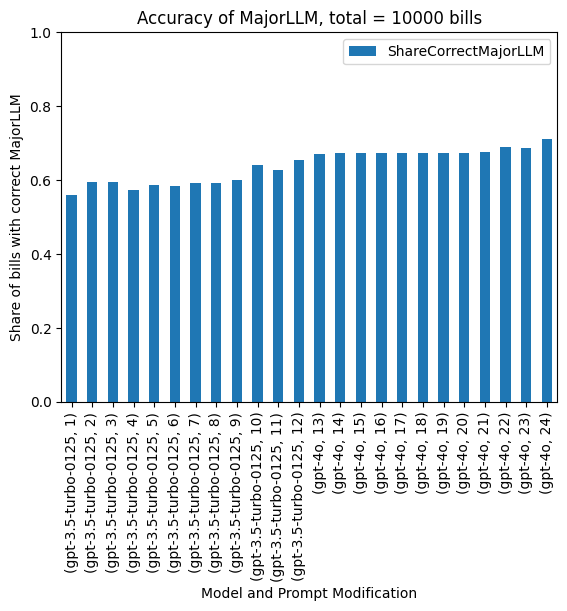

In [18]:
prompts_and_responses_path = os.path.join(llm_dir, f"prompts_and_responses_{n}.csv")
prompts_and_responses = pd.read_csv(prompts_and_responses_path)
prompts_and_responses["CorrectMajorLLM"] = prompts_and_responses["Major"] == prompts_and_responses["MajorLLM"]
stat = prompts_and_responses.groupby(["Model", "PromptingStrategyID"]).agg(
    ShareCorrectMajorLLM = ("CorrectMajorLLM", "mean")
).plot(kind="bar", 
       title=f'Accuracy of MajorLLM, total = {n_bills} bills',
       xlabel='Model and Prompt Modification',
       ylabel='Share of bills with correct MajorLLM',
       ylim=(0,1)) 


In [ ]:
# stat = prompts_and_responses[prompts_and_responses["PromptingStrategyName"]=="Few-Shot"].groupby(["BillID"]).agg(
#     UniqueMajorLLM = ("MajorLLM", "nunique")
#     ).reset_index()

# labels, counts = np.unique(stat["UniqueMajorLLM"], return_counts=True)
# plt.bar(labels, counts, align='center')
# plt.gca().set_xticks(labels)
# plt.title(f'Histogram of unique MajorLLM in few-shot prompts, across {n_bills} bills')
# plt.xlabel('Number of unique MajorLLM')
# plt.ylabel('Number of Bills')
# plt.show()